# World Happiness Report EDA Project

This project analyzes the World Happiness Report 2019 dataset to understand which factors are most strongly related to happiness scores across countries.

In [1]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("happiness_data")

print("Files extracted successfully!")

Files extracted successfully!


## 1. Data Loading

The dataset was loaded using Pandas. It contains happiness scores and related factors for 156 countries.

In [2]:
import os

print(os.listdir("happiness_data"))

['2018.csv', '2015.csv', '2016.csv', '2019.csv', '2017.csv']


## 2. Data Cleaning

I checked the dataset for missing values and duplicates. Since the dataset was already clean, no major cleaning was required.

In [3]:
import pandas as pd

df = pd.read_csv("happiness_data/2019.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (156, 9)

Columns:
Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 2. Data Cleaning

I checked the dataset for missing values and duplicates. Since the dataset was already clean, no major cleaning was required.

In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


## 3. Top 10 Happiest Countries

This chart shows the countries with the highest happiness scores in the dataset.

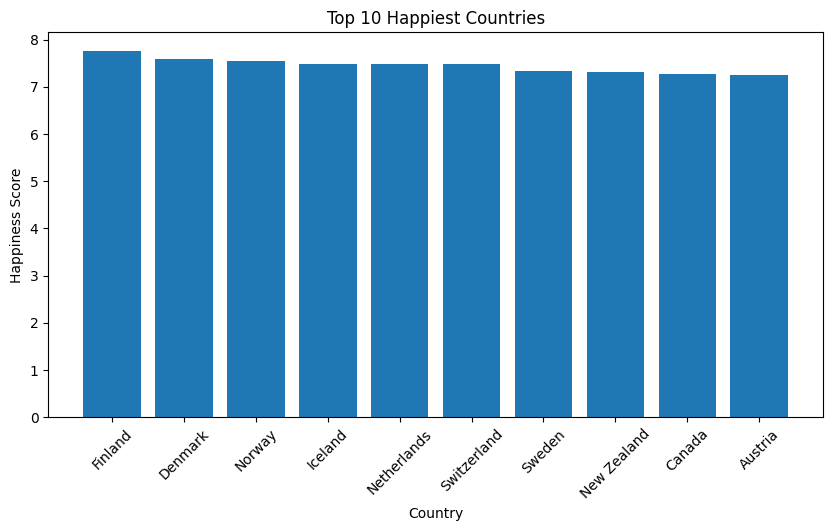

In [5]:
import matplotlib.pyplot as plt

top10 = df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Country or region"], top10["Score"])
plt.xticks(rotation=45)
plt.title("Top 10 Happiest Countries")
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.show()

## 4. GDP vs Happiness Score

This scatter plot shows the relationship between GDP per capita and happiness score.

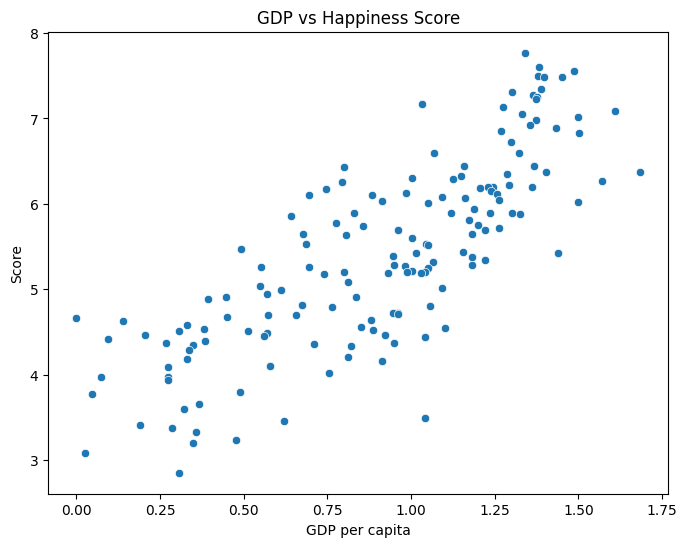

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="GDP per capita",
    y="Score",
    data=df
)

plt.title("GDP vs Happiness Score")
plt.show()

## 5. Correlation Heatmap

The heatmap helps identify which factors have the strongest relationship with happiness score.

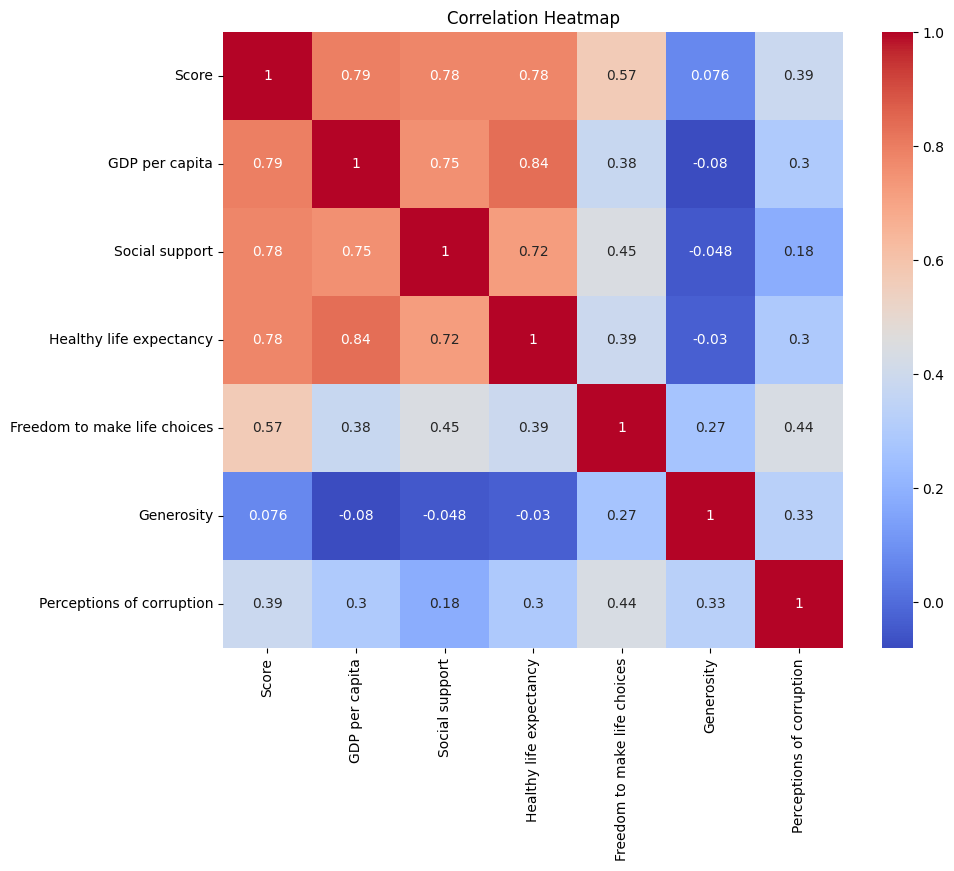

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop(["Overall rank", "Country or region"], axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
correlation = df.drop(["Overall rank", "Country or region"], axis=1).corr()

print(correlation["Score"].sort_values(ascending=False))

Score                           1.000000
GDP per capita                  0.793883
Healthy life expectancy         0.779883
Social support                  0.777058
Freedom to make life choices    0.566742
Perceptions of corruption       0.385613
Generosity                      0.075824
Name: Score, dtype: float64


## 6. Factors Affecting Happiness

This bar chart shows the correlation of different factors with happiness score.

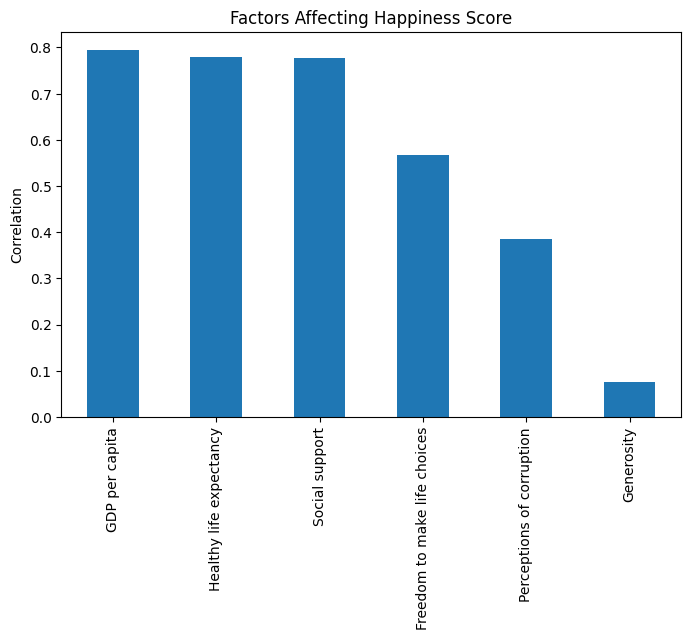

In [9]:
import matplotlib.pyplot as plt

correlation["Score"].sort_values(ascending=False)[1:].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Factors Affecting Happiness Score")
plt.ylabel("Correlation")
plt.show()

## 7. Bottom 10 Happiest Countries

This chart shows the countries with the lowest happiness scores in the dataset.

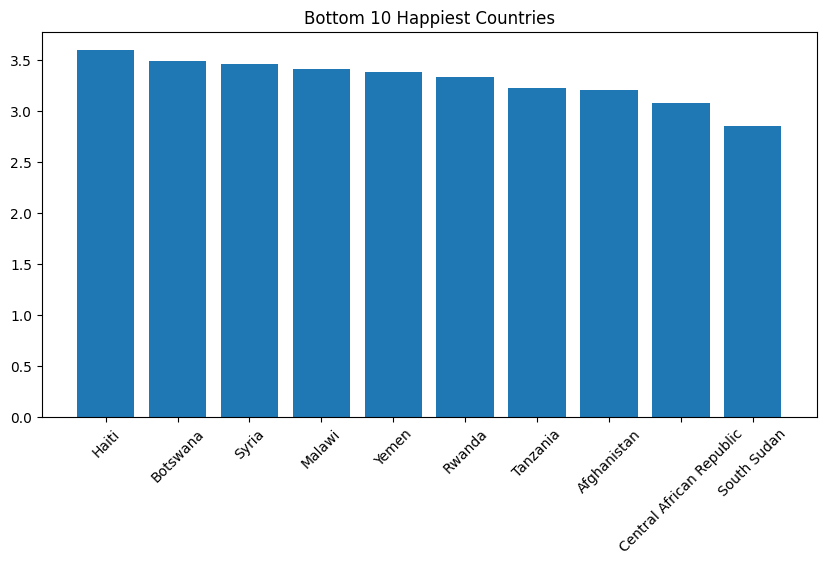

In [10]:
bottom10 = df.tail(10)

plt.figure(figsize=(10,5))
plt.bar(bottom10["Country or region"], bottom10["Score"])
plt.xticks(rotation=45)
plt.title("Bottom 10 Happiest Countries")
plt.show()

In [11]:
plt.savefig("happiness_factors.png")

<Figure size 640x480 with 0 Axes>

## Key Findings

1. Finland is the happiest country in the dataset.
2. South Sudan has the lowest happiness score.
3. GDP per capita shows the strongest positive relationship with happiness.
4. Healthy life expectancy and social support are also highly correlated with happiness.
5. Generosity has the weakest correlation with happiness score.

## Conclusion

The analysis suggests that countries with higher GDP, better healthcare, and stronger social support systems generally report higher happiness scores. Economic and social factors play a significant role in determining overall happiness.